# Distributed Parallelism Strategies - Consolidated Index\n
**Date**: 2026-05-31  \n
**Objective**: Provide a single runnable notebook to index, validate, and summarize all distributed parallelism notebooks in this folder.

In [1]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def load_runtime_env() -> None:
    env_files = [
        Path("configs/runtime.env"),
        Path("configs/runtime.env.example"),
        Path("../configs/runtime.env"),
        Path("../configs/runtime.env.example"),
    ]
    for env_file in env_files:
        if env_file.exists():
            for line in env_file.read_text(encoding="utf-8").splitlines():
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))
            break

load_runtime_env()
print(f"Seed set to {SEED}")

Seed set to 42


In [2]:
import importlib.util

def parse_use_gpu_flag(raw_value: str) -> bool:
    normalized = raw_value.strip().lower()
    return normalized not in {"0", "false", "no", "off"}

USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))

_torch_cuda = False
_tf_gpu = False
if importlib.util.find_spec("torch") is not None:
    import torch

    _torch_cuda = torch.cuda.is_available()
if importlib.util.find_spec("tensorflow") is not None:
    import tensorflow as tf

    tf.random.set_seed(SEED)
    _tf_gpu = bool(tf.config.list_physical_devices("GPU"))

RUNTIME_DEVICE = "cuda" if USE_GPU and (_torch_cuda or _tf_gpu) else "cpu"

@dataclass(frozen=True)
class IndexConfig:
    base_dir: str = "distributed-parallelism-strategies"
    expected_notebooks: int = 5

CFG = IndexConfig()
print(f"USE_GPU={int(USE_GPU)} | runtime_device={RUNTIME_DEVICE}")
CFG

USE_GPU=1 | runtime_device=cuda


IndexConfig(base_dir='distributed-parallelism-strategies', expected_notebooks=5)

In [3]:
def load_notebook_paths(cfg: IndexConfig) -> List[Path]:
    candidates = [
        Path(cfg.base_dir),
        Path("."),
        Path("distributed-parallelism-strategies"),
        Path("../distributed-parallelism-strategies"),
    ]
    for root in candidates:
        if not root.exists():
            continue
        files = sorted(
            p for p in root.glob("*.ipynb") if not p.name.endswith("_tested.ipynb")
        )
        if files:
            return files
    raise FileNotFoundError(
        "No notebooks found in expected distributed-parallelism-strategies paths."
    )

nb_paths = load_notebook_paths(CFG)
[p.name for p in nb_paths]

['00-consolidated-index.ipynb',
 '01-basic-distributed-parallelism.ipynb',
 '02-advanced-distributed-parallelism.ipynb',
 '03-framework-runnable-patterns.ipynb',
 '04-distributed-launch-command-builders.ipynb']

In [4]:
def preprocess_names(paths: List[Path]) -> List[Dict[str, str]]:

    rows: List[Dict[str, str]] = []

    for idx, p in enumerate(paths, start=1):

        stem = p.stem

        stage = stem.split("-", 1)[0] if "-" in stem else "misc"

        rows.append(

            {

                "order": str(idx),

                "file": p.name,

                "stage": stage,

            }

        )

    return rows



rows = preprocess_names(nb_paths)

rows


[{'order': '1', 'file': '00-consolidated-index.ipynb', 'stage': '00'},
 {'order': '2',
  'file': '01-basic-distributed-parallelism.ipynb',
  'stage': '01'},
 {'order': '3',
  'file': '02-advanced-distributed-parallelism.ipynb',
  'stage': '02'},
 {'order': '4', 'file': '03-framework-runnable-patterns.ipynb', 'stage': '03'},
 {'order': '5',
  'file': '04-distributed-launch-command-builders.ipynb',
  'stage': '04'}]

In [5]:
def define_progression_model(rows: List[Dict[str, str]]) -> List[Dict[str, str]]:

    modeled: List[Dict[str, str]] = []

    for r in rows:

        file_name = r["file"]

        if file_name.startswith("00-"):

            track = "Index"

        elif file_name.startswith("01-"):

            track = "Basic"

        elif file_name.startswith("02-"):

            track = "Advanced"

        elif file_name.startswith("03-"):

            track = "Framework Patterns"

        elif file_name.startswith("04-"):

            track = "Command Builders"

        else:

            track = "Other"

        modeled.append({**r, "track": track})

    return modeled



modeled_rows = define_progression_model(rows)

modeled_rows


[{'order': '1',
  'file': '00-consolidated-index.ipynb',
  'stage': '00',
  'track': 'Index'},
 {'order': '2',
  'file': '01-basic-distributed-parallelism.ipynb',
  'stage': '01',
  'track': 'Basic'},
 {'order': '3',
  'file': '02-advanced-distributed-parallelism.ipynb',
  'stage': '02',
  'track': 'Advanced'},
 {'order': '4',
  'file': '03-framework-runnable-patterns.ipynb',
  'stage': '03',
  'track': 'Framework Patterns'},
 {'order': '5',
  'file': '04-distributed-launch-command-builders.ipynb',
  'stage': '04',
  'track': 'Command Builders'}]

In [6]:
def train_run_plan(modeled_rows: List[Dict[str, str]]) -> List[Dict[str, str]]:
    # Training stage builds executable run sequence commands.
    plans: List[Dict[str, str]] = []
    for r in modeled_rows:
        cmd = (
            "jupyter nbconvert --to notebook --execute "
            f"distributed-parallelism-strategies/{r['file']} "
            f"--output-dir distributed-parallelism-strategies/tested "
            f"--output {r['file'].replace('.ipynb', '_tested.ipynb')}"
        )
        plans.append({**r, "run_cmd": cmd})
    return plans

plans = train_run_plan(modeled_rows)
plans[:1]

[{'order': '1',
  'file': '00-consolidated-index.ipynb',
  'stage': '00',
  'track': 'Index',
  'run_cmd': 'jupyter nbconvert --to notebook --execute distributed-parallelism-strategies/00-consolidated-index.ipynb --output-dir distributed-parallelism-strategies/tested --output 00-consolidated-index_tested.ipynb'}]

In [7]:
def evaluate_index(plans: List[Dict[str, str]], cfg: IndexConfig) -> Dict[str, float]:

    found = len(plans)

    expected = cfg.expected_notebooks

    coverage = found / expected if expected else 0.0

    return {

        "found_notebooks": float(found),

        "expected_notebooks": float(expected),

        "coverage": coverage,

    }



metrics = evaluate_index(plans, CFG)

metrics


{'found_notebooks': 5.0, 'expected_notebooks': 5.0, 'coverage': 1.0}

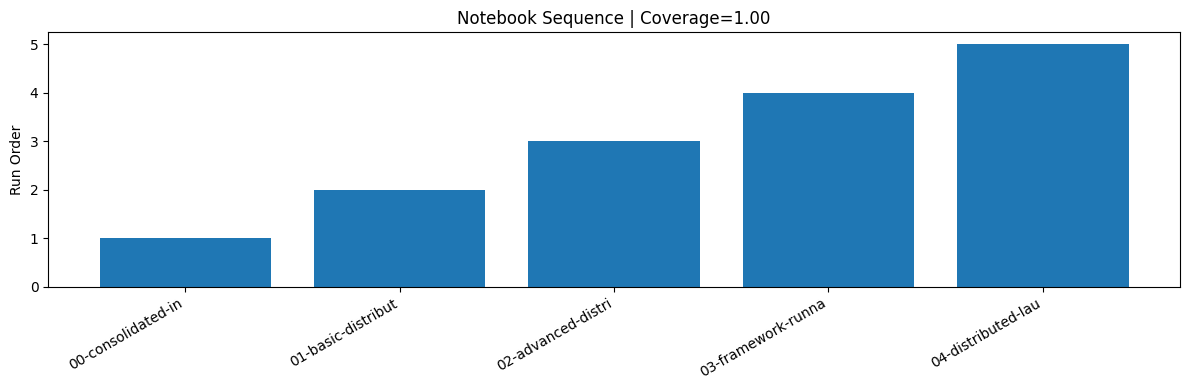

Run Sequence:
1. 00-consolidated-index.ipynb [Index]
2. 01-basic-distributed-parallelism.ipynb [Basic]
3. 02-advanced-distributed-parallelism.ipynb [Advanced]
4. 03-framework-runnable-patterns.ipynb [Framework Patterns]
5. 04-distributed-launch-command-builders.ipynb [Command Builders]


In [8]:
def visualize_plan(plans: List[Dict[str, str]], metrics: Dict[str, float]) -> None:

    labels = [p["file"][:18] for p in plans]

    values = np.arange(1, len(plans) + 1)



    plt.figure(figsize=(12, 4))

    plt.bar(labels, values)

    plt.xticks(rotation=30, ha="right")

    plt.ylabel("Run Order")

    plt.title(f"Notebook Sequence | Coverage={metrics['coverage']:.2f}")

    plt.tight_layout()

    plt.show()



    print("Run Sequence:")

    for p in plans:

        print(f"{p['order']}. {p['file']} [{p['track']}]")



visualize_plan(plans, metrics)


## Summary / Conclusions\n
\n
- This notebook consolidates and validates the run order of all distributed parallelism notebooks in one place.\n
- It generates executable nbconvert commands for each notebook and computes coverage metrics.\n
- Use this as the entry point before running detailed basic, advanced, and framework notebooks.